In [1]:
from tensorflow import keras

In [47]:
keras.utils.set_random_seed(1234)
(train_data,train_labels),(test_data,test_labels) = keras.datasets.mnist.load_data()

train_data = train_data.reshape(60000,28*28)
test_data = test_data.reshape(10000,28*28)

In [48]:
num_classes = 10
train_labels = keras.utils.to_categorical(train_labels,num_classes)
test_labels = keras.utils.to_categorical(test_labels,num_classes)

In [49]:
train_data = train_data.astype('float32') / 255
test_data = test_data.astype('float32') / 255

In [64]:
from numpy._core.fromnumeric import shape
from tensorflow.keras.layers import Input,Dense


model = keras.Sequential([
    Input(shape=(28*28,)),
    Dense(512,activation='relu'),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [65]:
history = model.fit(
    train_data,
    train_labels,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9268 - loss: 0.2507 - val_accuracy: 0.9697 - val_loss: 0.1018
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9716 - loss: 0.0932 - val_accuracy: 0.9767 - val_loss: 0.0791
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9831 - loss: 0.0559 - val_accuracy: 0.9785 - val_loss: 0.0755
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9889 - loss: 0.0363 - val_accuracy: 0.9748 - val_loss: 0.0860
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9923 - loss: 0.0257 - val_accuracy: 0.9753 - val_loss: 0.0908
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9940 - loss: 0.0200 - val_accuracy: 0.9742 - val_loss: 0.1083
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9935 - loss: 0.0201 - val_accuracy: 0.9768 - val_loss: 0.0917
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9949 - loss: 0.0152 - val_accuracy: 0.

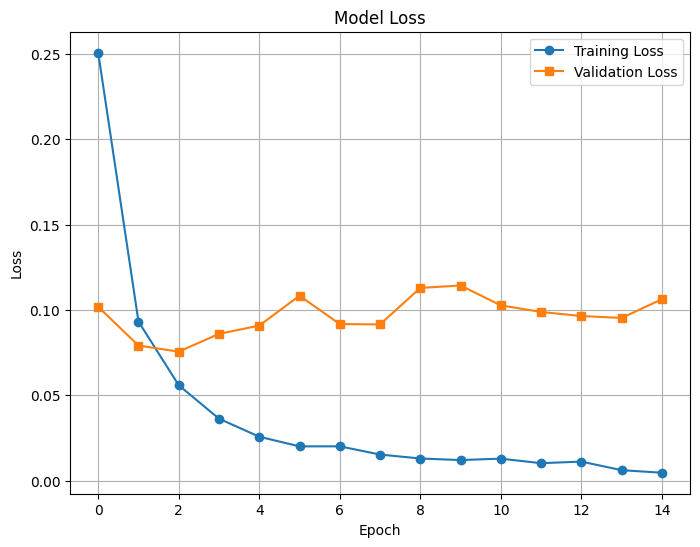

In [66]:
from matplotlib import pyplot as plt

plt.figure(figsize = (8, 6))
plt.plot(history.history['loss'], label = 'Training Loss', marker = 'o')
plt.plot(history.history['val_loss'], label = 'Validation Loss', marker = 's')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
from keras.regularizers import l1

model = keras.Sequential([
    Input(shape=(28*28,)),
    Dense(512,activation='relu',kernel_regularizer=l1(0.001)),
    Dense(128,activation='relu',kernel_regularizer=l1(0.001)),
    Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    train_labels,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8732 - loss: 2.7556 - val_accuracy: 0.9263 - val_loss: 0.8253
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9093 - loss: 0.7471 - val_accuracy: 0.9335 - val_loss: 0.6032
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9215 - loss: 0.6096 - val_accuracy: 0.9388 - val_loss: 0.5281
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9272 - loss: 0.5552 - val_accuracy: 0.9412 - val_loss: 0.4955
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9305 - loss: 0.5257 - val_accuracy: 0.9445 - val_loss: 0.4742
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9330 - loss: 0.5057 - val_accuracy: 0.9447 - val_loss: 0.4594
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9354 - loss: 0.4907 - val_accuracy: 0.9475 - val_loss: 0.4474
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9370 - loss: 0.4787 - val_accuracy: 0.

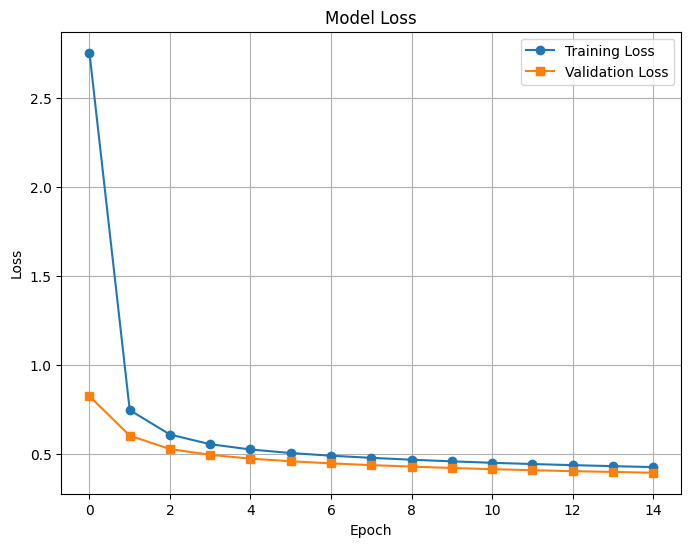

In [60]:
from matplotlib import pyplot as plt

plt.figure(figsize = (8, 6))
plt.plot(history.history['loss'], label = 'Training Loss', marker = 'o')
plt.plot(history.history['val_loss'], label = 'Validation Loss', marker = 's')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()